In [1]:
install.packages("wooldridge")
library(wooldridge)
data(lawsch85)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
?lawsch85

In [13]:
names(lawsch85)

[1] "rank"    "salary"  "cost"    "LSAT"    "GPA"     "libvol"  "faculty"
 [8] "age"     "clsize"  "north"   "south"   "east"    "west"    "lsalary"
[15] "studfac" "top10"   "r11_25"  "r26_40"  "r41_60"  "llibvol" "lcost"

Respuesta "1" Los datos utilizados para la ejecución del código corresponde a un estudio sobre los datos de las escuelas de derecho en 1985, con 156 observaciones y 21 variables:
salary: salario inicial mediano

cost: costo de la escuela de derecho

LSAT: puntaje mediano del LSAT

GPA: promedio de notas universitarias (GPA) mediano

libvol: número de volúmenes en la biblioteca (en miles)

faculty: número de profesores

age: antigüedad de la escuela de derecho (en años)

clsize: tamaño de la clase de ingreso
north: =1 si la escuela de derecho está en el norte

south: =1 si la escuela de derecho está en el sur

east: =1 si la escuela de derecho está en el este

west: =1 si la escuela de derecho está en el oeste

lsalary: logaritmo del salario

studfac: relación estudiante-profesor

top10: =1 si está en el top 10 del ranking

r11_25: =1 si está rankeada entre 11-25

r26_40: =1 si está rankeada entre 26-40

r41_60: =1 si está rankeada entre 41-60

llibvol: logaritmo de libvol

lcost: logaritmo del costo

In [3]:
summary (lawsch85)

      rank            salary           cost            LSAT      
 Min.   :  1.00   Min.   :24900   Min.   : 2623   Min.   :140.0  
 1st Qu.: 40.75   1st Qu.:29950   1st Qu.: 9664   1st Qu.:155.0  
 Median : 83.50   Median :34725   Median :12898   Median :158.0  
 Mean   : 83.75   Mean   :38947   Mean   :12736   Mean   :158.3  
 3rd Qu.:125.50   3rd Qu.:41350   3rd Qu.:16129   3rd Qu.:161.0  
 Max.   :175.00   Max.   :78325   Max.   :20518   Max.   :171.0  
                  NA's   :8       NA's   :6       NA's   :6      
      GPA            libvol          faculty            age        
 Min.   :2.730   Min.   : 124.0   Min.   : 17.00   Min.   :  3.00  
 1st Qu.:3.200   1st Qu.: 235.0   1st Qu.: 45.00   1st Qu.: 63.50  
 Median :3.300   Median : 302.0   Median : 58.00   Median : 85.00  
 Mean   :3.303   Mean   : 347.1   Mean   : 70.73   Mean   : 85.82  
 3rd Qu.:3.410   3rd Qu.: 400.0   3rd Qu.: 86.25   3rd Qu.:112.50  
 Max.   :3.820   Max.   :1745.0   Max.   :245.00   Max.   :206.0

**PREGUNTA 2**
Existen variables que poseen datos perdidios es decir NA y por tanto las observaciones no logran sumar 156 observaciones.

El salario inicial presenta un promedio de 38.947 y una mediana de 34.725, evidenciando asimetría positiva (presencia de valores altos).

Las variables académicas (LSAT = 158.3, GPA = 3.303) muestran baja variabilidad, indicando homogeneidad en la calidad de los estudiantes.

En contraste, los recursos institucionales (faculty, libvol) presentan alta dispersión, reflejando diferencias importantes entre universidades.

El ranking promedio es 83.75, con baja proporción de escuelas de élite (top 10), lo que sugiere predominio de instituciones de nivel medio.

El tamaño de generación (clsize) también es variable, con promedio de 241 estudiantes.

Existen datos faltantes, especialmente en age, lo que puede afectar análisis posteriores.

In [4]:
install.packages("corrplot")
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



Warning message in text.default(pos.xlabel[, 1], pos.xlabel[, 2], newcolnames, srt = tl.srt, :
“"addcoef.col" is not a graphical parameter”
Warning message in text.default(pos.ylabel[, 1], pos.ylabel[, 2], newrownames, col = tl.col, :
“"addcoef.col" is not a graphical parameter”
Warning message in title(title, ...):
“"addcoef.col" is not a graphical parameter”


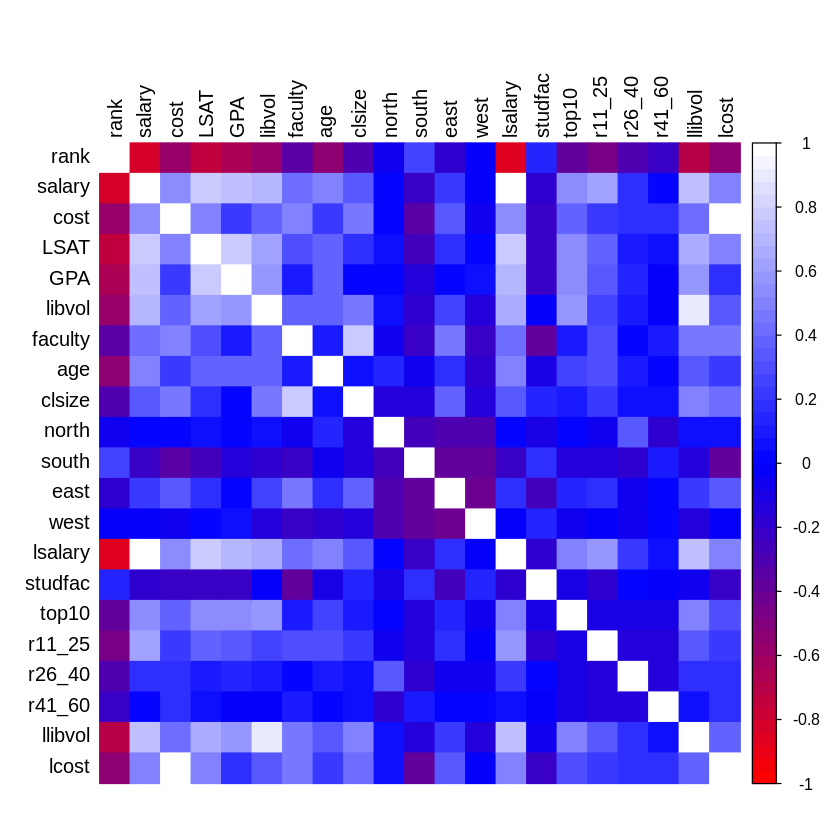

In [9]:
cor_matrix <- cor(lawsch85, use = "complete.obs")
corrplot(cor_matrix, method = "color", col = colorRampPalette(c( "red","blue", "white" ))(50), tl.cex =1, tl.col = "black", number.cex = 0.9, addcoef.col= "black")

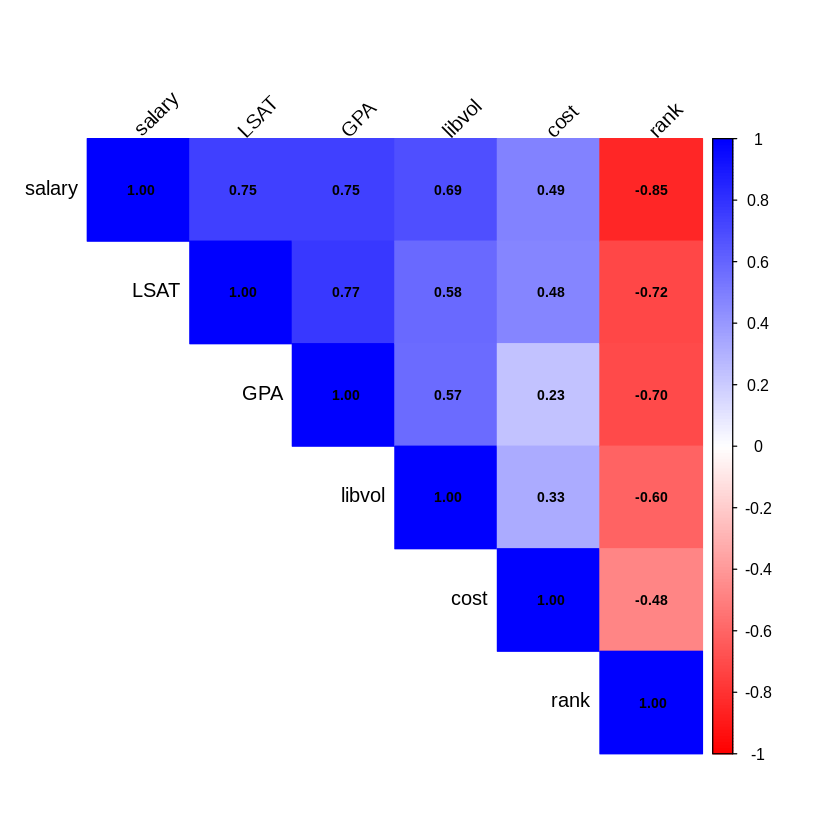

In [6]:
X <- na.omit(lawsch85[, c("salary", "LSAT", "GPA", "libvol", "cost", "rank")])
#salary → salario inicial mediano de los egresados
#LSAT → puntaje mediano del examen de admisión a derecho (mide calidad de estudiantes)
#GPA → promedio de notas universitarias de ingreso (rendimiento académico)
#libvol → número de volúmenes en la biblioteca (en miles) → mide recursos académicos
#cost → costo de estudiar en la escuela de derecho
#rank → posición en el ranking (1 = mejor, números más altos = peor posición)

# Calcular matriz de correlaciones
cor_mat <- cor(X)

# Graficar matriz de correlaciones
corrplot(cor_mat,
         method = "color",
         type = "upper",
         addCoef.col = "black",  # Añadir valores de correlación en negro
         tl.col = "black",       # Color de las etiquetas
         tl.srt = 45,            # Rotación de etiquetas
         col = colorRampPalette(c("red","white","blue"))(200), # escala de colores
         number.cex = 0.7)       # Tamaño de los números


**Pregunta 3**
1. Definir que nuestra variable dependiente sera salario dado que es lo que estamos buscando medir en base al estudio.
2. Recordar el concepto de MULTICOLINEALIDAD: 2 o más variables explicativas significan o explican lo mismo o algo muy parecido.
3. Posibles problemas y que no deberiamos incluir ambas en un modelo:
   LSAT GPA = 0.77

   rank – LSAT = -0.72

     rank – GPA = -0.70

4. Analisis final: La variable rank muestra la correlación más fuerte con el salario inicial (-0.85). Esto indica que pertenecer a una escuela mejor posicionada en el ranking se asocia a salarios iniciales más altos. Asimismo, el desempeño académico (LSAT y GPA) presenta correlaciones positivas importantes (~0.75). Los recursos de la institución, como el tamaño de la biblioteca y el costo, también correlacionan positivamente con los salarios, aunque en menor medida.

In [10]:
datos <- na.omit(lawsch85[, c("salary", "LSAT")])

modelo_simple <- lm(log(salary) ~ LSAT, data = datos)

# Resumen del modelo
summary(modelo_simple)



Call:
lm(formula = log(salary) ~ LSAT, data = datos)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39909 -0.11847 -0.00006  0.11981  0.48594 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.57939    0.50973   7.022  8.5e-11 ***
LSAT         0.04393    0.00322  13.645  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1826 on 141 degrees of freedom
Multiple R-squared:  0.5691,	Adjusted R-squared:  0.566 
F-statistic: 186.2 on 1 and 141 DF,  p-value: < 2.2e-16


**Pregunta 4**
Como leer un modelo log en la vriable dependiente: Un cambio de 1 unidad en X (variables independientes) provoca un cambio **porcentual** en Y (variable dependiente). es decir el Beta debe multiplicarse por 100.

Por lo tanto quedaria definido como: Log(salary)=3.579+0.0439⋅LSAT

***Un aumento de 1 punto en el puntaje del test de admision incrementa el salario en aproximadamente 4,39%, en promedio.***

In [11]:
datos_multi <- subset(lawsch85, !is.na(salary) & !is.na(LSAT) &
                                    !is.na(GPA) & !is.na(libvol) &
                                    !is.na(cost) & cost > 0 & !is.na(rank))

mod_multi <- lm(log(salary) ~ LSAT + GPA + log(libvol) + log(cost) + rank,
                data = datos_multi)
summary(mod_multi)


Call:
lm(formula = log(salary) ~ LSAT + GPA + log(libvol) + log(cost) + 
    rank, data = datos_multi)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.301356 -0.084982 -0.004359  0.077935  0.288614 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  8.3432262  0.5325192  15.667  < 2e-16 ***
LSAT         0.0046965  0.0040105   1.171  0.24372    
GPA          0.2475238  0.0900371   2.749  0.00683 ** 
log(libvol)  0.0949932  0.0332544   2.857  0.00499 ** 
log(cost)    0.0375539  0.0321061   1.170  0.24427    
rank        -0.0033246  0.0003485  -9.541  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1124 on 130 degrees of freedom
Multiple R-squared:  0.8417,	Adjusted R-squared:  0.8356 
F-statistic: 138.2 on 5 and 130 DF,  p-value: < 2.2e-16


**Pregunta 5:**
El intercepto no es interpretable porque representa una situación que no se observa en la realidad. Es decir las variables independiente nunca van a tomar esos valores. EJ: el ranking comienza en el 1.

LSAT (0.0046965)
Un aumento de 1 punto en el puntaje del test de admision está asociado a un aumento de aproximadamente 0,47% en el salario, ceteris paribus.
No es significativo (p = 0.24, NUlos *)

GPA (0.2475)
Un aumento de 1 punto en GPA está asociado a un aumento de aproximadamente 24,75% en el salario, ceteris paribus.
Significativo al 5 y al 10 %.

log(libvol) (0.09499) (log-log)
Un aumento de 1% en el número de volúmenes de la biblioteca está asociado a un aumento de aproximadamente 0,095% en el salario, ceteris paribus.
Significativo al 5 y al 10 %.

log(cost) (0.03755) (log-log)
Un aumento de 1% en el costo está asociado a un aumento de aproximadamente 0,038% en el salario, ceteris paribus.
No significativo

Un aumento de 1 posición en el ranking (peor ranking) está asociado a una disminución de aproximadamente 0,33% en el salario, ceteris paribus.
 Muy significativo al 1, 5 y 10 %


Por lo tanto podemos definir que:

**Modelo basico** Un aumento de una unidad de X aumenta en promedio B1 unidades de Y.

**Log- Log:** Un aumento de 1% en X aumenta en promedio B1% unidades de Y.

**Log en la variable dependiente:** Un aumento de una unidad de X aumenta en promedio b1*100 % unidades de Y.

**Log en la variable independiente:** Un aumento de 1% en X aumenta en promediO b1/100 unidades de Y.

Respuesta 6 En la regresión simple, el puntaje en el test de admision parecía explicar bien el salario (≈4.4% más por punto, R² = 0.57). Sin embargo, al incluir más variables en el modelo múltiple, su efecto cayó a 0.47% y dejó de ser significativo, evidenciando **sesgo por omisión**. Las variables más relevantes resultaron ser GPA *Promedio general*(≈25% más por punto), log(libvol) V*olumen de la biblioteca*(elasticidad positiva) y rank *(un peor puesto reduce salario en 0.33%)*. El costo tuvo efecto positivo pero no significativo. El ajuste mejoró notablemente (R² ajustado = 0.84), mostrando que el salario depende de una combinación de calidad académica, recursos y prestigio institucional. Esto demuestra que un buen modelo debe incluir variables relevantes para evitar sesgos en los coeficientes, ya que la omisión de variables importantes puede hacer que otras variables absorban su efecto o sobreestimen su impacto.